<a href="https://colab.research.google.com/github/kaxmarc/statistics_ml/blob/main/individual_exercise/exercise_2-1/exercise_2_1_individual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Chapter 2 – Individual Exercise 1: Decision Tree
by Kay Müller

Dataset: **Medical Cost Personal Datasets**

Source: https://www.kaggle.com/datasets/mirichoi0218/insurance

Using scikit-learn, train and compare three different tree-based regression models, specifically:

DecisionTreeRegressor; RandomForestRegressor; ExtraTreesRegressor (Extremely Randomized Trees)

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet

##1. Dataset

In [57]:
# Load Kaggle dataset from my GitHub Repo
df = pd.read_csv('https://raw.githubusercontent.com/kaxmarc/statistics_ml/refs/heads/main/datasets/insurance.csv')
# df.head()
print("Shape", df.shape)


Shape (1338, 7)


##2. Preprocessing

In [58]:
# Copy for preparation
df_optimised = df.copy()

# Check Missing Values
missing_values = df_optimised.isnull().sum().sort_values(ascending=False)
if missing_values.sum() > 0: print(f"\n{'='*55}\nImportant: Edit missing values!\n{'='*55}")

numerical_col = df_optimised.select_dtypes(include=np.number).columns.tolist()
categorical_col = df_optimised.select_dtypes(include=['object', 'category']).columns.tolist()

df_optimised = pd.get_dummies(df_optimised, columns=categorical_col, drop_first=False)

"""
Attempt to use LabelEncoder, which led to misleading representation (ranking)
in the region group, among other things (0<1<2...), this prompted
me to use OneHotEncoder again.

# label_encoder:

label_encoder = {}

for col in categorical_col:
  label = LabelEncoder()
  df_optimised[col] = label.fit_transform(df_optimised[col])
  label_encoder[col] = label
  print(f" -{col}: {len(label.classes_)} categories")
"""

# Preliminary examination
# What is the relationship between age, BMI and children and medical costs?
print("\n" + "="*70)
print(" CORRELATIONS WITH TARGET(charges)")
print("="*70)

numeric_features = ['age', 'bmi', 'children']
for feature in numeric_features:
    corr = df[feature].corr(df['charges'])
    print(f"{feature:15s} → charges: {corr:+.4f}")


print(f"\nCategories encoded by ohe (pd):")
df_optimised.head()




 CORRELATIONS WITH TARGET(charges)
age             → charges: +0.2990
bmi             → charges: +0.1983
children        → charges: +0.0680

Categories encoded by ohe (pd):


,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


##3. Features

In [59]:
# Separate feature and target
X = df_optimised.drop(columns=['charges'])
y = df_optimised['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, random_state=42
)
print(f"Training data 80%: {X_train.shape[0]} Samples",
      f"\nTest data 20%:     {y_test.shape[0]} Samples"
)


Training data 80%: 1070 Samples 
Test data 20%:     268 Samples


##4. Evaluation and metrics functions

In [60]:
def evaluate(model, model_name, X_train, X_test, y_train, y_test):

  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)

  tr_mse = mean_squared_error(y_train, y_train_pred)
  tr_rmse = np.sqrt(tr_mse)
  tr_r2 = r2_score(y_train, y_train_pred)

  te_mse = mean_squared_error(y_test, y_test_pred)
  te_rmse = np.sqrt(te_mse)
  te_r2 = r2_score(y_test, y_test_pred)

  # Key Values for dynamic queries
  return {
      "tr_mse": tr_mse,
      "tr_rmse": tr_rmse,
      "tr_r2": tr_r2,
      "te_mse": te_mse,
      "te_rmse": te_rmse,
      "te_r2": te_r2,
      "y_test_pred": y_test_pred
  }

def metrics(model_name, metrics):
    print(f"\n{'='*55}",
        f"\n {model_name}"
        f"\n{'='*55}",
        f"\n\n Training:"
        f"\n ---------------------------"
        f"\n  MSE:    {metrics['tr_mse']:,.2f}"
        f"\n  RMSE:   {metrics['tr_rmse']:,.2f}"
        f"\n  R2:     {metrics['tr_r2']:,.3f}"
        f"\n\n Testing:"
        f"\n ---------------------------"
        f"\n  MSE:    {metrics['te_mse']:,.2f}"
        f"\n  RMSE:   {metrics['te_rmse']:,.2f}"
        f"\n  R2:     {metrics['te_r2']:,.3f}"
    )

##**5.1 DecisionTreeRegressor**

In [61]:
dtr_model = DecisionTreeRegressor(random_state=42)
dtr_model.fit(X_train, y_train)

d_tree_metrics = evaluate(dtr_model, "DecisionTreeRegressor", X_train, X_test, y_train, y_test)
metrics("DecisionTreeRegressor", d_tree_metrics)


 DecisionTreeRegressor

 Training:
 ---------------------------
  MSE:    244,239.55
  RMSE:   494.21
  R2:     0.998

 Testing:
 ---------------------------
  MSE:    37,981,594.47
  RMSE:   6,162.92
  R2:     0.755


Interpretation of results:

Training very good (R2 = 0.998) <-> Test worse (R2 = 0.755). This represents a difference of 24%. The tree grows very deep, which prevents it from generalising well to new, unseen data due to the learning level.

***In section 7.1, I will examine a solution approach using L1/L2 regularisation and boosting.***



##**5.2 RandomForestRegressor**

In [62]:
rfr_model = RandomForestRegressor(n_estimators=100, random_state=42)
rfr_model.fit(X_train, y_train)

r_forest_metrics = evaluate(rfr_model, "RandomForestRegressor", X_train, X_test, y_train, y_test)
metrics("RandomForestRegressor", r_forest_metrics)


 RandomForestRegressor

 Training:
 ---------------------------
  MSE:    3,632,466.83
  RMSE:   1,905.90
  R2:     0.975

 Testing:
 ---------------------------
  MSE:    21,051,837.12
  RMSE:   4,588.23
  R2:     0.864


Interpretation of results:

Training very good (R2 = 0.975) <-> Test very good (R2 = 0.864).

With a difference of only 11% and the generally high score, the model generalises very well. In addition, the model excels with a low RMSE of 4,588 monetary units.

***Under point 7.2, I will add an optimisation approach – hyperparameter tuning.***

##**5.3 ExtraTreesRegressor (Extremely Randomized Trees)**

In [63]:
etr_model = ExtraTreesRegressor(n_estimators=100, random_state=42)
etr_model.fit(X_train, y_train)

e_tree_metrics = evaluate(etr_model, "ExtraTreesRegressor", X_train, X_test, y_train, y_test)
metrics("ExtraTreesRegressor", e_tree_metrics)


 ExtraTreesRegressor

 Training:
 ---------------------------
  MSE:    244,239.55
  RMSE:   494.21
  R2:     0.998

 Testing:
 ---------------------------
  MSE:    24,397,746.70
  RMSE:   4,939.41
  R2:     0.843


Interpretation of results:

Training very good (R2 = 0.998) <-> Test good (R2 = 0.843).

The ExtraTreesRegressor ranks between the two previous models. With a score difference of just under 16%, it is more affected by overfitting, as is the Decision Tree. I assume that in this case, the (random) splits or extreme randomisation weigh more heavily on the guessing than on "real" learning.

##6. Predicted vs. actual scatter plot

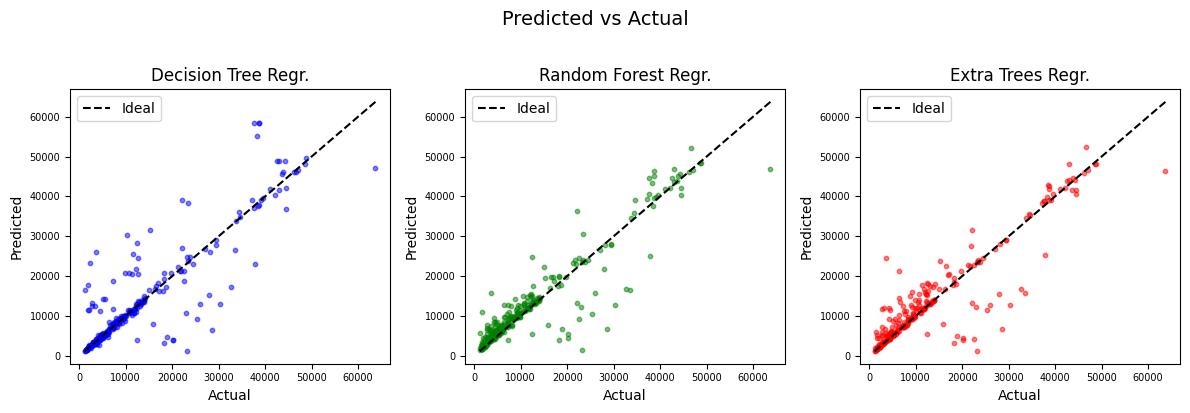

In [64]:
# 3 Plots
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

models_data = [
  ('Decision Tree Regr.', d_tree_metrics['y_test_pred'], 'blue'),
  ('Random Forest Regr.', r_forest_metrics['y_test_pred'], 'green'),
  ('Extra Trees Regr.', e_tree_metrics['y_test_pred'], 'red')
]

# For every plot
for ax, (name, y_pred, color) in zip(axes, models_data):
  # Scatter Plot
  ax.scatter(y_test, y_pred, alpha=0.5, color=color, s=10)

  # Ideal line (y = x)
  min_val = min(y_test.min(), y_pred.min())
  max_val = max(y_test.max(), y_pred.max())
  ax.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')

  ax.set_xlabel('Actual')
  ax.set_ylabel('Predicted')
  ax.set_title(f'{name}')
  ax.tick_params(axis='both', labelsize=7)
  ax.legend()

plt.suptitle('Predicted vs Actual', fontsize=14, y=1.02)
plt.subplots_adjust(wspace=5)
plt.tight_layout()
plt.show()

In [65]:
# Comparison table
comparison_data = {
  'Modell': ['Decision Tree', 'Random Forest', 'Extra Trees'],
  'Train MSE': [d_tree_metrics['tr_mse'], r_forest_metrics['tr_mse'], e_tree_metrics['tr_mse']],
  'Test MSE': [d_tree_metrics['te_mse'], r_forest_metrics['te_mse'], e_tree_metrics['te_mse']],
  'Train RMSE': [d_tree_metrics['tr_rmse'], r_forest_metrics['tr_rmse'], e_tree_metrics['tr_rmse']],
  'Test RMSE': [d_tree_metrics['te_rmse'], r_forest_metrics['te_rmse'], e_tree_metrics['te_rmse']],
  'Train R2': [d_tree_metrics['tr_r2'], r_forest_metrics['tr_r2'], e_tree_metrics['tr_r2']],
  'Test R2': [d_tree_metrics['te_r2'], r_forest_metrics['te_r2'], e_tree_metrics['te_r2']]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*90)
print(" MODEL COMPARISON - SUMMARY")
print("="*90)
comparison_df


 MODEL COMPARISON - SUMMARY


,Modell,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R2,Test R2
0,Decision Tree,2.442396e+05,3.798159e+07,494.205984,6162.920936,0.998308,0.755350
1,Random Forest,3.632467e+06,2.105184e+07,1905.903154,4588.228102,0.974833,0.864399
2,Extra Trees,2.442396e+05,2.439775e+07,494.205984,4939.407525,0.998308,0.842847


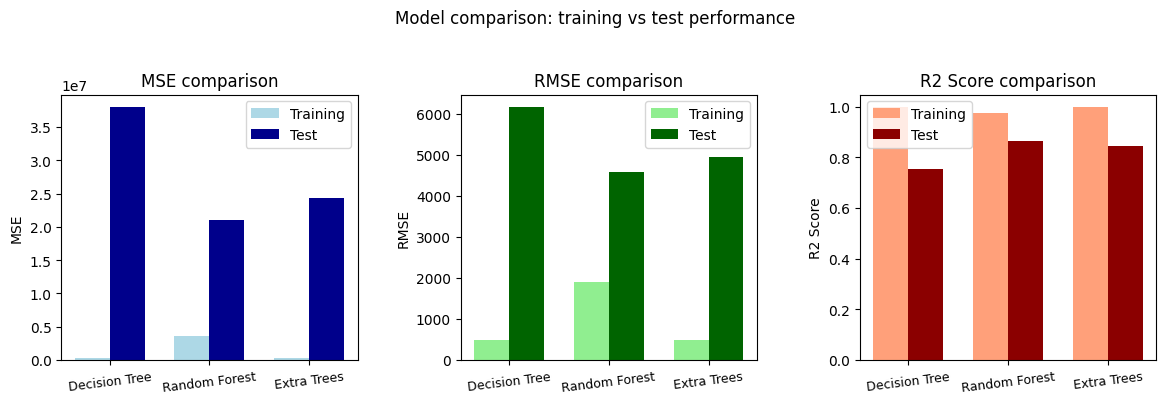

In [66]:
# 3 Plots
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

models = ['Decision Tree', 'Random Forest', 'Extra Trees']
colors = ['blue', 'green', 'red']
x = np.arange(len(models))
width = 0.35

# MSE comparison
train_mse = [d_tree_metrics['tr_mse'], r_forest_metrics['tr_mse'], e_tree_metrics['tr_mse']]
test_mse = [d_tree_metrics['te_mse'], r_forest_metrics['te_mse'], e_tree_metrics['te_mse']]
axes[0].bar(x - width/2, train_mse, width, label='Training', color='lightblue')
axes[0].bar(x + width/2, test_mse, width, label='Test', color='darkblue')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=7, fontsize=9)
axes[0].set_ylabel('MSE')
axes[0].set_title('MSE comparison')
axes[0].legend()

# RMSE comparison
train_rmse = [d_tree_metrics['tr_rmse'], r_forest_metrics['tr_rmse'], e_tree_metrics['tr_rmse']]
test_rmse = [d_tree_metrics['te_rmse'], r_forest_metrics['te_rmse'], e_tree_metrics['te_rmse']]
axes[1].bar(x - width/2, train_rmse, width, label='Training', color='lightgreen')
axes[1].bar(x + width/2, test_rmse, width, label='Test', color='darkgreen')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=7, fontsize=9)
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE comparison')
axes[1].legend()

# R2 comparison
train_r2 = [d_tree_metrics['tr_r2'], r_forest_metrics['tr_r2'], e_tree_metrics['tr_r2']]
test_r2 = [d_tree_metrics['te_r2'], r_forest_metrics['te_r2'], e_tree_metrics['te_r2']]
axes[2].bar(x - width/2, train_r2, width, label='Training', color='lightsalmon')
axes[2].bar(x + width/2, test_r2, width, label='Test', color='darkred')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=7, fontsize=9)
axes[2].set_ylabel('R2 Score')
axes[2].set_title('R2 Score comparison')
axes[2].legend()

plt.suptitle('Model comparison: training vs test performance', fontsize=12, y=1)
plt.subplots_adjust(wspace=5)
plt.tight_layout()
plt.show()

In [67]:
# Overfitting-Analyse
print("\n" + "="*90)
print("  OVERFITTING ANALYSIS (difference between train R2 and test R2)")
print("="*90)
print(f"\n  Decision Tree:  {d_tree_metrics['tr_r2'] - d_tree_metrics['te_r2']:.4f}")
print(f"  Random Forest:  {r_forest_metrics['tr_r2'] - r_forest_metrics['te_r2']:.4f}")
print(f"  Extra Trees:    {e_tree_metrics['tr_r2'] - e_tree_metrics['te_r2']:.4f}")
print("\n  -> Lower values = better generalisation new unseen data.")


  OVERFITTING ANALYSIS (difference between train R2 and test R2)

  Decision Tree:  0.2430
  Random Forest:  0.1104
  Extra Trees:    0.1555

  -> Lower values = better generalisation new unseen data.


In [68]:
# Best model
print("\n" + "="*90)
print("  RECOMMENDATION")
print("="*90)

test_r2_scores = {
  'Decision Tree': d_tree_metrics['te_r2'],
  'Random Forest': r_forest_metrics['te_r2'],
  'Extra Trees': e_tree_metrics['te_r2']
}

best_model = max(test_r2_scores, key=test_r2_scores.get)
best_score = test_r2_scores[best_model]

print(f"\n  Best model (according to test R2): {best_model}")
print(f"  Test R2 Score: {best_score:.4f}")


  RECOMMENDATION

  Best model (according to test R2): Random Forest
  Test R2 Score: 0.8644


##7. Erweiterte Versuche und Untersuchungen

##**7.1 Ridge, Lasso und GradientBoosting**

In [69]:

# Ridge (L2)
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)
ridge_metrics = evaluate(ridge_model, "Ridge (L2)", X_train, X_test, y_train, y_test)
metrics("Ridge (L2)", ridge_metrics)

# Lasso (L1)
lasso_model = Lasso(alpha=1.0, random_state=42)
lasso_model.fit(X_train, y_train)
lasso_metrics = evaluate(lasso_model, "Lasso (L1)", X_train, X_test, y_train, y_test)
metrics("Lasso (L1)", lasso_metrics)

# GradientBoosting
gb_model = GradientBoostingRegressor(
  n_estimators=200,
  learning_rate=0.1,
  max_depth=5,
  min_samples_split=20,
  min_samples_leaf=10,
  random_state=42
)
gb_model.fit(X_train, y_train)
gb_metrics = evaluate(gb_model, "GradientBoosting", X_train, X_test, y_train, y_test)
metrics("GradientBoosting", gb_metrics)


 Ridge (L2)

 Training:
 ---------------------------
  MSE:    37,278,435.07
  RMSE:   6,105.61
  R2:     0.742

 Testing:
 ---------------------------
  MSE:    33,619,947.01
  RMSE:   5,798.27
  R2:     0.783

 Lasso (L1)

 Training:
 ---------------------------
  MSE:    37,277,711.06
  RMSE:   6,105.55
  R2:     0.742

 Testing:
 ---------------------------
  MSE:    33,605,932.38
  RMSE:   5,797.06
  R2:     0.784

 GradientBoosting

 Training:
 ---------------------------
  MSE:    10,715,076.09
  RMSE:   3,273.39
  R2:     0.926

 Testing:
 ---------------------------
  MSE:    20,409,963.29
  RMSE:   4,517.74
  R2:     0.869


##**7.2 Hyperparameter tuning (RandomForestRegressor)**

In [70]:
param_distributions = {
  'n_estimators': [200, 300, 400],
  'max_depth': [15, 20, 25],
  'min_samples_split': [5, 10, 15],
  'min_samples_leaf': [2, 5, 10],
  'max_features': ['sqrt', 0.7]
}

random_search = RandomizedSearchCV(
  RandomForestRegressor(random_state=42, n_jobs=-1),
  param_distributions,
  n_iter=20,
  cv=5,
  scoring='r2',
  n_jobs=-1,
  random_state=42
)

random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_

r_forest_metrics = evaluate(rfr_model, "RandomForestRegressor (tuned)", X_train, X_test, y_train, y_test)
metrics("RandomForestRegressor (tuned)", r_forest_metrics)


 RandomForestRegressor (tuned)

 Training:
 ---------------------------
  MSE:    3,632,466.83
  RMSE:   1,905.90
  R2:     0.975

 Testing:
 ---------------------------
  MSE:    21,051,837.12
  RMSE:   4,588.23
  R2:     0.864


#Fazit

## DecisionTreeRegressor
Single decision tree with recursive data partitioning, which is easy to interpret. However, it has a strong tendency to overfitting, which is reflected in the evaluation.
**Training R2 = 0,998 <-> Test R2 = 0,755**

## RandomForestRegressor
Each tree in the forest trains on a random sample, which makes the model more robust and allows for averaging. The model is significantly less prone to overfitting.
**Training R2 = 0,975 <-> Test R2 = 0,864**

## Optimisation approach Hyperparameter Tuning RandomForestRegressor:
As described in section 7.1, RandomForestRegressor was significantly optimised once again using hyperparameter tuning. With a **score difference of only 6% (previously 11%)**, the risk of overfitting has been significantly reduced once again. The model is able to recognise real patterns and train efficiently on new, unseen data.

## ExtraTreesRegressor
In the context of random forests, this model works with more random splits. However, in my research, it did not show any advantage over random forests. Only the risk of overfitting is significantly lower than with decision trees.
**Training R2 = 0.998 <-> Test R2 = 0,843**

## Tree Summary (derived)

| Aspekt | Decision Tree | Random Forest | Extra Trees |
|--------|--------------|---------------|-------------|
| Overfitting risk | High | Low | Medium |
| Generalisation | Average | Good | Good |
| Interpretability | High | Low | Low |
---
## Other models: GradientBoosting, Ridge L2 und Lasso L1
With regard to the decision tree, I tested three additional models, whereby Lasso and Ridge are better at explaining than the decision tree. However, GradientBoosting ranks at the top with a score difference of less than 6%, closely following the optimised RandomForestRegressor.

